In [2]:
# ============================================================
# BEST MODEL OPTIMIZATION - LINEAR SVM
# NOTEBOOK 2
# ============================================================

import os
import re
import json
import time
import joblib
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("=" * 70)
print("LINEAR SVM OPTIMIZATION - SETUP COMPLETE")
print("=" * 70)

LINEAR SVM OPTIMIZATION - SETUP COMPLETE


In [3]:
# ============================================================
# STEP 2 - PROJECT PATHS
# ============================================================

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "Classification_Model"
)

BASELINE_MODEL_PATH = (
    BASE_DIR
    / "models"
    / "best_baseline_expense_category_model.joblib"
)

TRAIN_FILE = (
    BASE_DIR
    / "splits"
    / "train_split.csv"
)

VAL_FILE = (
    BASE_DIR
    / "splits"
    / "validation_split.csv"
)

TEST_FILE = (
    BASE_DIR
    / "splits"
    / "test_split.csv"
)


OPT_MODEL_DIR = (
    BASE_DIR
    / "optimized_models"
)

OPT_REPORT_DIR = (
    BASE_DIR
    / "optimization_reports"
)

OPT_FIGURE_DIR = (
    BASE_DIR
    / "optimization_figures"
)


OPT_MODEL_DIR.mkdir(exist_ok=True)
OPT_REPORT_DIR.mkdir(exist_ok=True)
OPT_FIGURE_DIR.mkdir(exist_ok=True)


print("=" * 70)
print("PATH CHECK")
print("=" * 70)

print("\nBaseline Model:")
print(BASELINE_MODEL_PATH)
print("Exists:", BASELINE_MODEL_PATH.exists())

print("\nTrain Split:")
print(TRAIN_FILE)
print("Exists:", TRAIN_FILE.exists())

print("\nValidation Split:")
print(VAL_FILE)
print("Exists:", VAL_FILE.exists())

print("\nTest Split:")
print(TEST_FILE)
print("Exists:", TEST_FILE.exists())

PATH CHECK

Baseline Model:
C:\Users\LENOVO\Desktop\Classification_Model\models\best_baseline_expense_category_model.joblib
Exists: True

Train Split:
C:\Users\LENOVO\Desktop\Classification_Model\splits\train_split.csv
Exists: True

Validation Split:
C:\Users\LENOVO\Desktop\Classification_Model\splits\validation_split.csv
Exists: True

Test Split:
C:\Users\LENOVO\Desktop\Classification_Model\splits\test_split.csv
Exists: True


In [4]:
# ============================================================
# STEP 3 - LOAD BASELINE MODEL
# ============================================================

if not BASELINE_MODEL_PATH.exists():

    raise FileNotFoundError(
        "Baseline model not found. "
        "Run Notebook 1 first."
    )


baseline_model = joblib.load(
    BASELINE_MODEL_PATH
)


print("=" * 70)
print("BASELINE MODEL LOADED")
print("=" * 70)

print("\nPipeline:")
print(baseline_model)

print("\nClassifier Type:")
print(
    type(
        baseline_model.named_steps["classifier"]
    ).__name__
)


if not isinstance(
    baseline_model.named_steps["classifier"],
    LinearSVC
):

    raise ValueError(
        "The selected baseline model is not Linear SVM."
    )


print("\nConfirmed: Linear SVM baseline model.")

BASELINE MODEL LOADED

Pipeline:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                 strip_accents='unicode', sublinear_tf=True)),
                ('classifier',
                 LinearSVC(class_weight='balanced', random_state=42))])

Classifier Type:
LinearSVC

Confirmed: Linear SVM baseline model.


In [5]:
# ============================================================
# STEP 4 - LOAD EXISTING SPLITS
# ============================================================

train_df = pd.read_csv(
    TRAIN_FILE
)

val_df = pd.read_csv(
    VAL_FILE
)

test_df = pd.read_csv(
    TEST_FILE
)


print("=" * 70)
print("DATA SPLITS LOADED")
print("=" * 70)

print("\nTrain Samples:")
print(len(train_df))

print("\nValidation Samples:")
print(len(val_df))

print("\nTest Samples:")
print(len(test_df))


print("\nTrain Classes:")
print(
    train_df["Category"]
    .value_counts()
    .sort_index()
)

DATA SPLITS LOADED

Train Samples:
5880

Validation Samples:
1260

Test Samples:
1260

Train Classes:
Category
Bills            420
Business         420
Education        420
Entertainment    420
Food             420
Gift             420
Health           420
Investment       420
OTP_REJECT       420
Others           420
Salary           420
Shopping         420
Transport        420
Travel           420
Name: count, dtype: int64


In [6]:
# ============================================================
# STEP 5 - VERIFY CLASS DISTRIBUTION
# ============================================================

split_distribution = pd.DataFrame({

    "Train":
        train_df["Category"]
        .value_counts(),

    "Validation":
        val_df["Category"]
        .value_counts(),

    "Test":
        test_df["Category"]
        .value_counts()

}).fillna(0).astype(int).sort_index()


print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

display(
    split_distribution
)


print(
    "\nNumber of Classes:",
    len(split_distribution)
)

CLASS DISTRIBUTION


,Train,Validation,Test
Category,,,
Bills,420,90,90
Business,420,90,90
Education,420,90,90
Entertainment,420,90,90
Food,420,90,90
Gift,420,90,90
Health,420,90,90
Investment,420,90,90
OTP_REJECT,420,90,90



Number of Classes: 14


In [7]:
# ============================================================
# STEP 6 - SMS NORMALIZATION
# ============================================================

def normalize_sms(text):

    text = str(text).lower()


    # Currency amounts
    text = re.sub(
        r'\b(?:lkr|rs\.?|rs)\s*[\d,]+(?:\.\d+)?',
        ' <AMOUNT> ',
        text,
        flags=re.IGNORECASE
    )


    # Decimal amounts
    text = re.sub(
        r'\b\d[\d,]*\.\d{1,2}\b',
        ' <AMOUNT> ',
        text
    )


    # Dates
    text = re.sub(
        r'\b\d{4}-\d{1,2}-\d{1,2}\b',
        ' <DATE> ',
        text
    )

    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        ' <DATE> ',
        text
    )


    # Time
    text = re.sub(
        r'\b\d{1,2}:\d{2}(?::\d{2})?\b',
        ' <TIME> ',
        text
    )


    # Masked accounts
    text = re.sub(
        r'(?:x|\*){3,}\d*',
        ' <ACCOUNT> ',
        text,
        flags=re.IGNORECASE
    )


    # OTP / reference numbers
    text = re.sub(
        r'\b\d{6,}\b',
        ' <REFERENCE> ',
        text
    )


    # Extra spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()


    return text


print("Normalization function ready.")

Normalization function ready.


In [8]:
# ============================================================
# STEP 7 - BASELINE VALIDATION EVALUATION
# ============================================================

baseline_val_pred = (
    baseline_model.predict(
        val_df["Clean_SMS"]
    )
)


baseline_val_accuracy = (
    accuracy_score(
        val_df["Category"],
        baseline_val_pred
    )
)


baseline_val_report = (
    classification_report(

        val_df["Category"],

        baseline_val_pred,

        output_dict=True,

        zero_division=0
    )
)


baseline_val_macro_f1 = (
    baseline_val_report[
        "macro avg"
    ]["f1-score"]
)


print("=" * 70)
print("BASELINE VALIDATION PERFORMANCE")
print("=" * 70)

print(
    "\nValidation Accuracy:",
    f"{baseline_val_accuracy * 100:.2f}%"
)

print(
    "Validation Macro F1:",
    f"{baseline_val_macro_f1 * 100:.2f}%"
)

BASELINE VALIDATION PERFORMANCE

Validation Accuracy: 99.84%
Validation Macro F1: 99.84%


In [9]:
# ============================================================
# STEP 8 - BASELINE FINAL TEST EVALUATION
# ============================================================

baseline_test_pred = (
    baseline_model.predict(
        test_df["Clean_SMS"]
    )
)


baseline_test_accuracy = (
    accuracy_score(
        test_df["Category"],
        baseline_test_pred
    )
)


baseline_test_report = (
    classification_report(

        test_df["Category"],

        baseline_test_pred,

        output_dict=True,

        zero_division=0
    )
)


baseline_test_macro_f1 = (
    baseline_test_report[
        "macro avg"
    ]["f1-score"]
)


baseline_test_weighted_f1 = (
    baseline_test_report[
        "weighted avg"
    ]["f1-score"]
)


print("=" * 70)
print("BASELINE TEST PERFORMANCE")
print("=" * 70)

print(
    "\nTest Accuracy:",
    f"{baseline_test_accuracy * 100:.2f}%"
)

print(
    "Macro F1:",
    f"{baseline_test_macro_f1 * 100:.2f}%"
)

print(
    "Weighted F1:",
    f"{baseline_test_weighted_f1 * 100:.2f}%"
)

BASELINE TEST PERFORMANCE

Test Accuracy: 100.00%
Macro F1: 100.00%
Weighted F1: 100.00%


In [10]:
# ============================================================
# STEP 9 - HARD UNSEEN SMS CHALLENGE SET
# ============================================================

challenge_samples = [

    # --------------------------------------------------------
    # FOOD
    # --------------------------------------------------------

    (
        "Debit card charged LKR 1840 at Green Bowl Cafe.",
        "Food"
    ),

    (
        "Rs 725 paid at Ocean View Restaurant using your card.",
        "Food"
    ),

    (
        "Purchase of LKR 1325 confirmed at City Bites.",
        "Food"
    ),

    (
        "Card debit 980 rupees at Morning Brew Coffee.",
        "Food"
    ),


    # --------------------------------------------------------
    # BILLS
    # --------------------------------------------------------

    (
        "Your broadband invoice payment of Rs 2490 was completed.",
        "Bills"
    ),

    (
        "LKR 860 charged for mobile postpaid bill.",
        "Bills"
    ),

    (
        "Electricity account payment Rs 5340 completed successfully.",
        "Bills"
    ),

    (
        "Utility payment of LKR 1125 processed from your bank account.",
        "Bills"
    ),


    # --------------------------------------------------------
    # SHOPPING
    # --------------------------------------------------------

    (
        "Debit card purchase Rs 6790 at Urban Wear Colombo.",
        "Shopping"
    ),

    (
        "LKR 12450 spent at Digital World Electronics.",
        "Shopping"
    ),

    (
        "Card used for retail purchase of Rs 3200 at Style Hub.",
        "Shopping"
    ),

    (
        "Purchase approved for LKR 4890 at Home Essentials Store.",
        "Shopping"
    ),


    # --------------------------------------------------------
    # TRANSPORT
    # --------------------------------------------------------

    (
        "Fuel purchase of LKR 7300 at Central Filling Station.",
        "Transport"
    ),

    (
        "Taxi ride payment Rs 1450 successfully charged.",
        "Transport"
    ),

    (
        "Bus travel card top-up LKR 600 completed.",
        "Transport"
    ),

    (
        "Highway toll payment of Rs 450 deducted from your account.",
        "Transport"
    ),


    # --------------------------------------------------------
    # TRAVEL
    # --------------------------------------------------------

    (
        "Hotel reservation payment LKR 28500 completed.",
        "Travel"
    ),

    (
        "Your airline booking was charged Rs 64000.",
        "Travel"
    ),

    (
        "Holiday package payment LKR 92000 successfully processed.",
        "Travel"
    ),

    (
        "Rs 18500 charged for accommodation booking.",
        "Travel"
    ),


    # --------------------------------------------------------
    # HEALTH
    # --------------------------------------------------------

    (
        "Medical consultation fee Rs 2800 paid successfully.",
        "Health"
    ),

    (
        "Card charged LKR 4650 at Sunrise Medical Centre.",
        "Health"
    ),

    (
        "Pharmacy purchase of Rs 1375 completed.",
        "Health"
    ),

    (
        "Laboratory test payment LKR 6200 deducted.",
        "Health"
    ),


    # --------------------------------------------------------
    # EDUCATION
    # --------------------------------------------------------

    (
        "Semester tuition payment of Rs 45000 completed.",
        "Education"
    ),

    (
        "Course registration fee LKR 12500 paid.",
        "Education"
    ),

    (
        "Exam fee payment of Rs 3500 was successful.",
        "Education"
    ),

    (
        "Payment LKR 8900 made to professional training institute.",
        "Education"
    ),


    # --------------------------------------------------------
    # ENTERTAINMENT
    # --------------------------------------------------------

    (
        "LKR 2400 charged for cinema tickets.",
        "Entertainment"
    ),

    (
        "Monthly music streaming subscription Rs 1100 renewed.",
        "Entertainment"
    ),

    (
        "Online gaming purchase of LKR 3500 completed.",
        "Entertainment"
    ),

    (
        "Entertainment event ticket payment Rs 7500 successful.",
        "Entertainment"
    ),


    # --------------------------------------------------------
    # SALARY
    # --------------------------------------------------------

    (
        "Employer credited LKR 128000 as September payroll.",
        "Salary"
    ),

    (
        "Monthly wage credit Rs 96500 received.",
        "Salary"
    ),

    (
        "Salary deposit of LKR 142500 received from employer.",
        "Salary"
    ),

    (
        "Payroll amount Rs 78000 credited to your bank account.",
        "Salary"
    ),


    # --------------------------------------------------------
    # BUSINESS
    # --------------------------------------------------------

    (
        "Client settlement of LKR 56000 credited to your account.",
        "Business"
    ),

    (
        "Rs 87500 received for completed consulting work.",
        "Business"
    ),

    (
        "Customer invoice payment LKR 43500 received.",
        "Business"
    ),

    (
        "Business service income of Rs 62000 credited.",
        "Business"
    ),


    # --------------------------------------------------------
    # INVESTMENT
    # --------------------------------------------------------

    (
        "Quarterly dividend of LKR 6800 credited.",
        "Investment"
    ),

    (
        "Investment interest payment Rs 3250 received.",
        "Investment"
    ),

    (
        "Treasury investment return LKR 11500 credited.",
        "Investment"
    ),

    (
        "Unit trust distribution Rs 9200 received.",
        "Investment"
    ),


    # --------------------------------------------------------
    # GIFT
    # --------------------------------------------------------

    (
        "Received LKR 15000 as wedding gift.",
        "Gift"
    ),

    (
        "Birthday gift Rs 5000 credited from family.",
        "Gift"
    ),

    (
        "Family member sent LKR 7500 as a personal gift.",
        "Gift"
    ),

    (
        "Rs 3000 received as celebration gift.",
        "Gift"
    ),


    # --------------------------------------------------------
    # OTHERS
    # --------------------------------------------------------

    (
        "ATM cash withdrawal LKR 8000 completed.",
        "Others"
    ),

    (
        "Generic bank transfer debit Rs 4750 completed.",
        "Others"
    ),

    (
        "Account-to-account transfer credit LKR 9300 received.",
        "Others"
    ),

    (
        "Cash deposit Rs 12000 successfully posted to your account.",
        "Others"
    ),


    # --------------------------------------------------------
    # OTP_REJECT
    # --------------------------------------------------------

    (
        "Use 483921 as your secure login verification code.",
        "OTP_REJECT"
    ),

    (
        "Your one time PIN is 771284. Never reveal it to anyone.",
        "OTP_REJECT"
    ),

    (
        "Banking authentication code 209884 expires shortly.",
        "OTP_REJECT"
    ),

    (
        "Enter verification code 556103 to confirm this device.",
        "OTP_REJECT"
    )
]


challenge_df = pd.DataFrame(

    challenge_samples,

    columns=[
        "SMS",
        "Expected"
    ]
)


challenge_df["Clean_SMS"] = (
    challenge_df["SMS"]
    .apply(
        normalize_sms
    )
)


print("=" * 70)
print("UNSEEN CHALLENGE SET CREATED")
print("=" * 70)

print(
    "\nTotal Challenge Messages:",
    len(challenge_df)
)

print("\nClass Distribution:")

print(
    challenge_df[
        "Expected"
    ]
    .value_counts()
    .sort_index()
)

UNSEEN CHALLENGE SET CREATED

Total Challenge Messages: 56

Class Distribution:
Expected
Bills            4
Business         4
Education        4
Entertainment    4
Food             4
Gift             4
Health           4
Investment       4
OTP_REJECT       4
Others           4
Salary           4
Shopping         4
Transport        4
Travel           4
Name: count, dtype: int64


In [11]:
# ============================================================
# STEP 10 - BASELINE UNSEEN CHALLENGE TEST
# ============================================================

baseline_challenge_pred = (
    baseline_model.predict(
        challenge_df["Clean_SMS"]
    )
)


challenge_df[
    "Baseline_Predicted"
] = baseline_challenge_pred


challenge_df[
    "Baseline_Correct"
] = (
    challenge_df[
        "Expected"
    ]
    ==
    challenge_df[
        "Baseline_Predicted"
    ]
)


baseline_challenge_accuracy = (
    challenge_df[
        "Baseline_Correct"
    ]
    .mean()
)


print("=" * 70)
print("BASELINE UNSEEN CHALLENGE TEST")
print("=" * 70)

print(
    "\nAccuracy:",
    f"{baseline_challenge_accuracy * 100:.2f}%"
)


print("\nWrong Predictions:")

display(

    challenge_df[
        challenge_df[
            "Baseline_Correct"
        ] == False
    ]
)

BASELINE UNSEEN CHALLENGE TEST

Accuracy: 98.21%

Wrong Predictions:


,SMS,Expected,Clean_SMS,Baseline_Predicted,Baseline_Correct
4,Your broadband invoice payment of Rs 2490 was ...,Bills,your broadband invoice payment of <AMOUNT> was...,Business,False


In [12]:
# ============================================================
# STEP 11 - BASELINE CHALLENGE CATEGORY PERFORMANCE
# ============================================================

baseline_challenge_category = (

    challenge_df

    .groupby(
        "Expected"
    )["Baseline_Correct"]

    .agg([
        "count",
        "sum"
    ])
)


baseline_challenge_category[
    "Accuracy_%"
] = (

    baseline_challenge_category[
        "sum"
    ]

    /

    baseline_challenge_category[
        "count"
    ]

    * 100
)


display(
    baseline_challenge_category.round(2)
)


baseline_challenge_category.to_csv(

    OPT_REPORT_DIR
    /
    "baseline_challenge_category_results.csv"
)

,count,sum,Accuracy_%
Expected,,,
Bills,4,3,75.0
Business,4,4,100.0
Education,4,4,100.0
Entertainment,4,4,100.0
Food,4,4,100.0
Gift,4,4,100.0
Health,4,4,100.0
Investment,4,4,100.0
OTP_REJECT,4,4,100.0


In [13]:
# ============================================================
# STEP 12 - LINEAR SVM OPTIMIZATION PIPELINE
# ============================================================

optimization_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode"
        )
    ),

    (
        "classifier",

        LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])


print("Optimization pipeline ready.")

Optimization pipeline ready.


In [14]:
# ============================================================
# STEP 13 - HYPERPARAMETER SEARCH SPACE
# ============================================================

parameter_grid = {

    "tfidf__ngram_range": [
        (1, 1),
        (1, 2),
        (1, 3)
    ],

    "tfidf__min_df": [
        1,
        2
    ],

    "tfidf__sublinear_tf": [
        True
    ],

    "tfidf__max_features": [
        20000,
        30000
    ],

    "classifier__C": [
        0.25,
        0.5,
        1.0,
        2.0
    ]
}


total_combinations = (

    len(
        parameter_grid[
            "tfidf__ngram_range"
        ]
    )

    *

    len(
        parameter_grid[
            "tfidf__min_df"
        ]
    )

    *

    len(
        parameter_grid[
            "tfidf__sublinear_tf"
        ]
    )

    *

    len(
        parameter_grid[
            "tfidf__max_features"
        ]
    )

    *

    len(
        parameter_grid[
            "classifier__C"
        ]
    )
)


print("=" * 70)
print("HYPERPARAMETER GRID")
print("=" * 70)

print(
    "\nTotal Configurations:",
    total_combinations
)

HYPERPARAMETER GRID

Total Configurations: 48


In [15]:
# ============================================================
# STEP 14 - PREDEFINED TRAIN / VALIDATION SPLIT FOR GRID SEARCH
# ============================================================

tune_df = pd.concat(

    [
        train_df,
        val_df
    ],

    ignore_index=True
)


X_tune = (
    tune_df[
        "Clean_SMS"
    ]
)


y_tune = (
    tune_df[
        "Category"
    ]
)


# -1 = training portion
#  0 = validation portion

test_fold = np.concatenate([

    np.full(
        len(train_df),
        -1
    ),

    np.zeros(
        len(val_df),
        dtype=int
    )
])


predefined_split = (
    PredefinedSplit(
        test_fold=test_fold
    )
)


print("=" * 70)
print("TUNING DATA READY")
print("=" * 70)

print(
    "\nTraining Portion:",
    len(train_df)
)

print(
    "Validation Portion:",
    len(val_df)
)

print(
    "Total Tuning Rows:",
    len(tune_df)
)

print(
    "\nTest set remains untouched:",
    len(test_df)
)

TUNING DATA READY

Training Portion: 5880
Validation Portion: 1260
Total Tuning Rows: 7140

Test set remains untouched: 1260


In [16]:
# ============================================================
# STEP 15 - GRID SEARCH OPTIMIZATION
# ============================================================

grid_search = GridSearchCV(

    estimator=
        optimization_pipeline,

    param_grid=
        parameter_grid,

    scoring=
        "f1_macro",

    cv=
        predefined_split,

    n_jobs=
        -1,

    verbose=
        1,

    refit=
        True,

    return_train_score=
        True
)


print("=" * 70)
print("GRID SEARCH STARTED")
print("=" * 70)


start_time = (
    time.time()
)


grid_search.fit(

    X_tune,

    y_tune
)


optimization_time = (
    time.time()
    -
    start_time
)


print("\n" + "=" * 70)
print("GRID SEARCH COMPLETE")
print("=" * 70)

print(
    "\nOptimization Time:",
    f"{optimization_time:.2f} seconds"
)

print(
    "\nBest Validation Macro F1:",
    f"{grid_search.best_score_ * 100:.2f}%"
)

print("\nBest Parameters:")

print(
    grid_search.best_params_
)

GRID SEARCH STARTED
Fitting 1 folds for each of 48 candidates, totalling 48 fits

GRID SEARCH COMPLETE

Optimization Time: 23.19 seconds

Best Validation Macro F1: 99.92%

Best Parameters:
{'classifier__C': 0.5, 'tfidf__max_features': 20000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}


In [17]:
# ============================================================
# STEP 16 - GRID SEARCH RESULTS
# ============================================================

grid_results_df = (
    pd.DataFrame(
        grid_search.cv_results_
    )
)


selected_columns = [

    "param_tfidf__ngram_range",

    "param_tfidf__min_df",

    "param_tfidf__max_features",

    "param_classifier__C",

    "mean_train_score",

    "mean_test_score",

    "rank_test_score"
]


grid_summary = (

    grid_results_df[
        selected_columns
    ]

    .sort_values(
        "rank_test_score"
    )

    .reset_index(
        drop=True
    )
)


grid_summary[
    "Train_Macro_F1_%"
] = (

    grid_summary[
        "mean_train_score"
    ]

    * 100
)


grid_summary[
    "Validation_Macro_F1_%"
] = (

    grid_summary[
        "mean_test_score"
    ]

    * 100
)


print("=" * 70)
print("TOP OPTIMIZATION CONFIGURATIONS")
print("=" * 70)


display(

    grid_summary[
        [
            "param_tfidf__ngram_range",
            "param_tfidf__min_df",
            "param_tfidf__max_features",
            "param_classifier__C",
            "Train_Macro_F1_%",
            "Validation_Macro_F1_%",
            "rank_test_score"
        ]
    ]
    .head(15)
    .round(3)
)


grid_summary.to_csv(

    OPT_REPORT_DIR
    /
    "grid_search_results.csv",

    index=False
)

TOP OPTIMIZATION CONFIGURATIONS


,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_features,param_classifier__C,Train_Macro_F1_%,Validation_Macro_F1_%,rank_test_score
0,"(1, 1)",1,20000,0.50,99.983,99.921,1
1,"(1, 1)",1,30000,1.00,100.000,99.921,1
2,"(1, 1)",1,20000,1.00,100.000,99.921,1
3,"(1, 1)",1,30000,0.50,99.983,99.921,1
4,"(1, 2)",1,20000,0.50,100.000,99.842,5
5,"(1, 1)",1,20000,0.25,99.966,99.842,5
6,"(1, 1)",1,30000,0.25,99.966,99.842,5
7,"(1, 2)",1,20000,0.25,99.966,99.842,5
8,"(1, 2)",1,30000,0.50,100.000,99.842,5
9,"(1, 2)",1,30000,1.00,100.000,99.842,5


In [18]:
# ============================================================
# STEP 17 - GET OPTIMIZED MODEL
# ============================================================

optimized_model = (
    grid_search.best_estimator_
)


print("=" * 70)
print("OPTIMIZED LINEAR SVM")
print("=" * 70)

print(
    optimized_model
)

OPTIMIZED LINEAR SVM
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, strip_accents='unicode',
                                 sublinear_tf=True)),
                ('classifier',
                 LinearSVC(C=0.5, class_weight='balanced', random_state=42))])


In [19]:
# ============================================================
# STEP 18 - OPTIMIZED MODEL FINAL TEST
# ============================================================

optimized_test_pred = (
    optimized_model.predict(
        test_df[
            "Clean_SMS"
        ]
    )
)


optimized_test_accuracy = (
    accuracy_score(
        test_df["Category"],
        optimized_test_pred
    )
)


optimized_test_report = (
    classification_report(

        test_df["Category"],

        optimized_test_pred,

        output_dict=True,

        zero_division=0
    )
)


optimized_test_macro_f1 = (
    optimized_test_report[
        "macro avg"
    ]["f1-score"]
)


optimized_test_weighted_f1 = (
    optimized_test_report[
        "weighted avg"
    ]["f1-score"]
)


print("=" * 70)
print("OPTIMIZED LINEAR SVM - FINAL TEST")
print("=" * 70)

print(
    "\nAccuracy:",
    f"{optimized_test_accuracy * 100:.2f}%"
)

print(
    "Macro F1:",
    f"{optimized_test_macro_f1 * 100:.2f}%"
)

print(
    "Weighted F1:",
    f"{optimized_test_weighted_f1 * 100:.2f}%"
)

OPTIMIZED LINEAR SVM - FINAL TEST

Accuracy: 100.00%
Macro F1: 100.00%
Weighted F1: 100.00%


In [20]:
# ============================================================
# STEP 19 - OPTIMIZED OTP_REJECT PERFORMANCE
# ============================================================

otp_metrics = (
    optimized_test_report[
        "OTP_REJECT"
    ]
)


print("=" * 70)
print("OPTIMIZED OTP_REJECT PERFORMANCE")
print("=" * 70)

print(
    "\nPrecision:",
    f"{otp_metrics['precision'] * 100:.2f}%"
)

print(
    "Recall:",
    f"{otp_metrics['recall'] * 100:.2f}%"
)

print(
    "F1:",
    f"{otp_metrics['f1-score'] * 100:.2f}%"
)

print(
    "Support:",
    int(
        otp_metrics[
            "support"
        ]
    )
)

OPTIMIZED OTP_REJECT PERFORMANCE

Precision: 100.00%
Recall: 100.00%
F1: 100.00%
Support: 90


In [21]:
# ============================================================
# STEP 20 - OPTIMIZED UNSEEN CHALLENGE TEST
# ============================================================

optimized_challenge_pred = (
    optimized_model.predict(
        challenge_df["Clean_SMS"]
    )
)


challenge_df[
    "Optimized_Predicted"
] = optimized_challenge_pred


challenge_df[
    "Optimized_Correct"
] = (
    challenge_df[
        "Expected"
    ]
    ==
    challenge_df[
        "Optimized_Predicted"
    ]
)


optimized_challenge_accuracy = (
    challenge_df[
        "Optimized_Correct"
    ]
    .mean()
)


print("=" * 70)
print("OPTIMIZED UNSEEN CHALLENGE TEST")
print("=" * 70)

print(
    "\nAccuracy:",
    f"{optimized_challenge_accuracy * 100:.2f}%"
)


print("\nWrong Predictions:")

display(

    challenge_df[
        challenge_df[
            "Optimized_Correct"
        ] == False
    ]
)

OPTIMIZED UNSEEN CHALLENGE TEST

Accuracy: 98.21%

Wrong Predictions:


,SMS,Expected,Clean_SMS,Baseline_Predicted,Baseline_Correct,Optimized_Predicted,Optimized_Correct
8,Debit card purchase Rs 6790 at Urban Wear Colo...,Shopping,debit card purchase <AMOUNT> at urban wear col...,Shopping,True,Bills,False


In [22]:
# ============================================================
# STEP 21 - BASELINE VS OPTIMIZED COMPARISON
# ============================================================

comparison_df = pd.DataFrame({

    "Metric": [

        "Validation Macro F1",

        "Test Accuracy",

        "Test Macro F1",

        "Test Weighted F1",

        "Unseen Challenge Accuracy"
    ],

    "Baseline Linear SVM": [

        baseline_val_macro_f1 * 100,

        baseline_test_accuracy * 100,

        baseline_test_macro_f1 * 100,

        baseline_test_weighted_f1 * 100,

        baseline_challenge_accuracy * 100
    ],

    "Optimized Linear SVM": [

        grid_search.best_score_ * 100,

        optimized_test_accuracy * 100,

        optimized_test_macro_f1 * 100,

        optimized_test_weighted_f1 * 100,

        optimized_challenge_accuracy * 100
    ]
})


comparison_df[
    "Difference"
] = (

    comparison_df[
        "Optimized Linear SVM"
    ]

    -

    comparison_df[
        "Baseline Linear SVM"
    ]
)


print("=" * 70)
print("BASELINE VS OPTIMIZED LINEAR SVM")
print("=" * 70)

display(
    comparison_df.round(2)
)


comparison_df.to_csv(

    OPT_REPORT_DIR
    /
    "baseline_vs_optimized.csv",

    index=False
)

BASELINE VS OPTIMIZED LINEAR SVM


,Metric,Baseline Linear SVM,Optimized Linear SVM,Difference
0,Validation Macro F1,99.84,99.92,0.08
1,Test Accuracy,100.00,100.00,0.00
2,Test Macro F1,100.00,100.00,0.00
3,Test Weighted F1,100.00,100.00,0.00
4,Unseen Challenge Accuracy,98.21,98.21,0.00


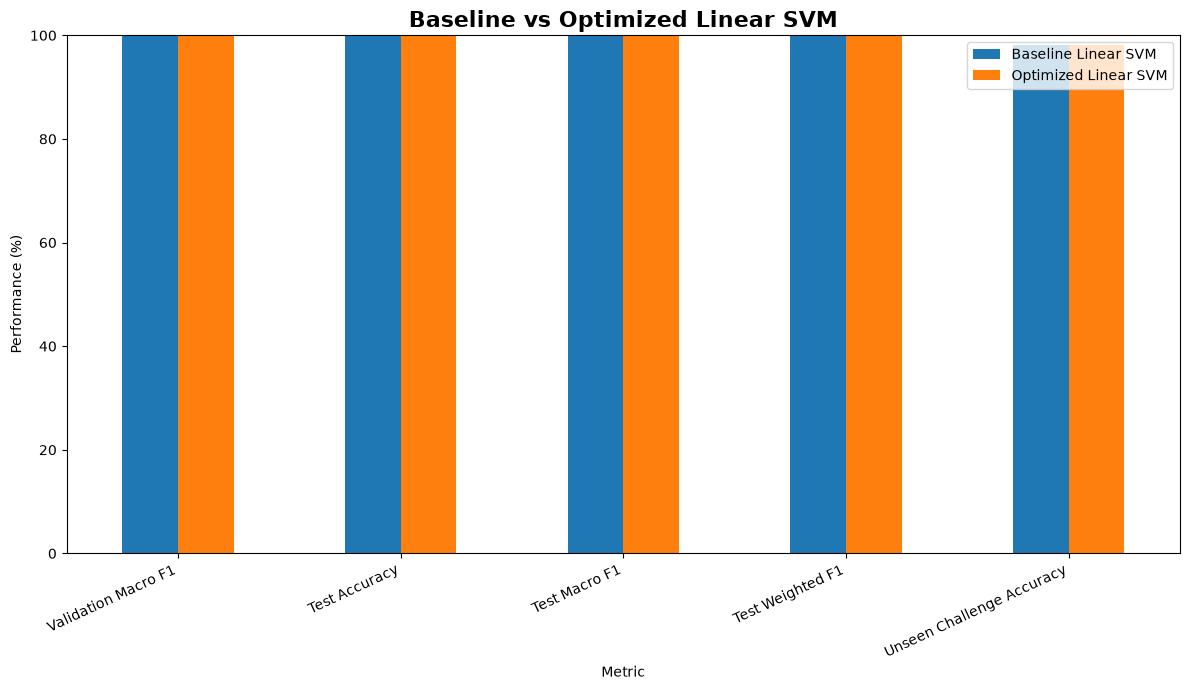

In [23]:
# ============================================================
# STEP 22 - BASELINE VS OPTIMIZED GRAPH
# ============================================================

graph_df = (

    comparison_df

    .set_index(
        "Metric"
    )

    [
        [
            "Baseline Linear SVM",
            "Optimized Linear SVM"
        ]
    ]
)


graph_df.plot(

    kind="bar",

    figsize=(12, 7)
)


plt.title(
    "Baseline vs Optimized Linear SVM",
    fontsize=16,
    fontweight="bold"
)


plt.ylabel(
    "Performance (%)"
)


plt.ylim(
    0,
    100
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


path = (

    OPT_FIGURE_DIR
    /
    "01_baseline_vs_optimized.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

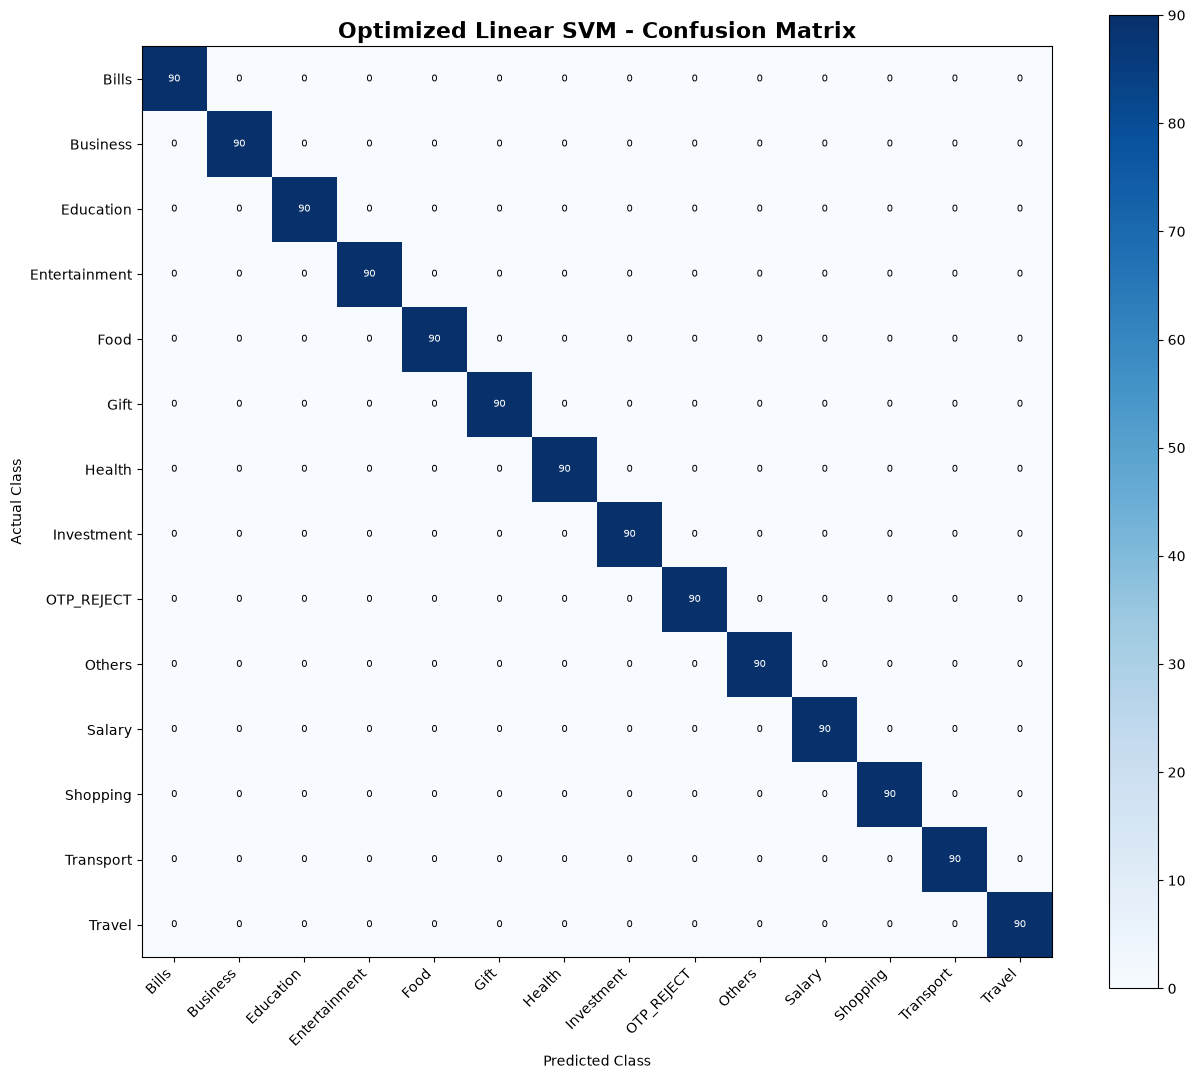

In [24]:
# ============================================================
# STEP 23 - OPTIMIZED CONFUSION MATRIX
# ============================================================

labels = sorted(
    test_df[
        "Category"
    ].unique()
)


cm = confusion_matrix(

    test_df[
        "Category"
    ],

    optimized_test_pred,

    labels=labels
)


plt.figure(
    figsize=(13, 11)
)


plt.imshow(
    cm,
    cmap="Blues"
)


plt.title(
    "Optimized Linear SVM - Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)


plt.xticks(
    range(
        len(labels)
    ),
    labels,
    rotation=45,
    ha="right"
)


plt.yticks(
    range(
        len(labels)
    ),
    labels
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


threshold = (
    cm.max()
    / 2
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(

            j,
            i,

            cm[i, j],

            ha="center",
            va="center",

            fontsize=7,

            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


plt.colorbar()

plt.tight_layout()


path = (

    OPT_FIGURE_DIR
    /
    "02_optimized_confusion_matrix.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

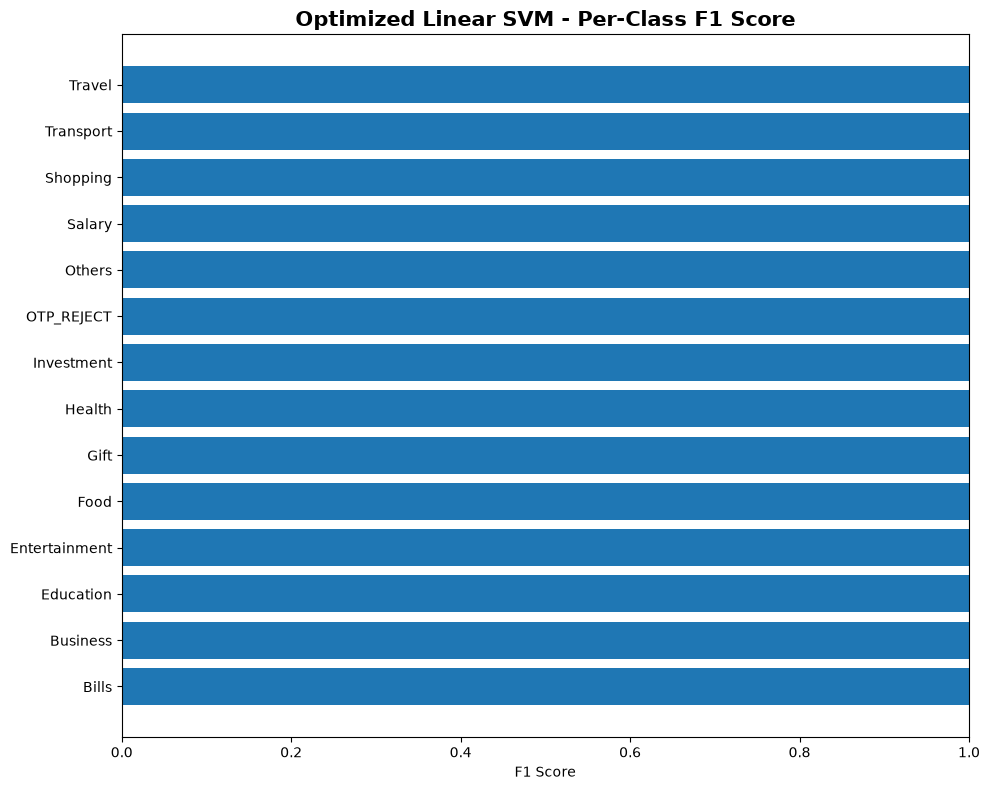

In [25]:
# ============================================================
# STEP 24 - OPTIMIZED PER-CLASS F1
# ============================================================

f1_rows = []


for category in labels:

    f1_rows.append({

        "Category":
            category,

        "F1":
            optimized_test_report[
                category
            ]["f1-score"]
    })


f1_df = (

    pd.DataFrame(
        f1_rows
    )

    .sort_values(
        "F1"
    )
)


plt.figure(
    figsize=(10, 8)
)


plt.barh(

    f1_df[
        "Category"
    ],

    f1_df[
        "F1"
    ]
)


plt.title(
    "Optimized Linear SVM - Per-Class F1 Score",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "F1 Score"
)


plt.xlim(
    0,
    1
)


plt.tight_layout()


path = (

    OPT_FIGURE_DIR
    /
    "03_optimized_class_f1.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [26]:
# ============================================================
# STEP 25 - SAVE OPTIMIZED MODEL
# ============================================================

OPTIMIZED_MODEL_PATH = (

    OPT_MODEL_DIR
    /
    "optimized_linear_svm.joblib"
)


joblib.dump(

    optimized_model,

    OPTIMIZED_MODEL_PATH
)


print("=" * 70)
print("OPTIMIZED MODEL SAVED")
print("=" * 70)

print(
    "\nSaved:",
    OPTIMIZED_MODEL_PATH
)

OPTIMIZED MODEL SAVED

Saved: C:\Users\LENOVO\Desktop\Classification_Model\optimized_models\optimized_linear_svm.joblib


In [27]:
# ============================================================
# STEP 26 - SAVE CHALLENGE RESULTS
# ============================================================

challenge_df.to_csv(

    OPT_REPORT_DIR
    /
    "unseen_challenge_results.csv",

    index=False
)


print(
    "Challenge results saved."
)

Challenge results saved.


In [28]:
# ============================================================
# STEP 27 - SAVE OPTIMIZATION METADATA
# ============================================================

optimization_metadata = {

    "baseline_model":
        "Linear SVM",

    "baseline_validation_macro_f1":
        float(
            baseline_val_macro_f1 * 100
        ),

    "baseline_test_accuracy":
        float(
            baseline_test_accuracy * 100
        ),

    "optimized_test_accuracy":
        float(
            optimized_test_accuracy * 100
        ),

    "optimized_test_macro_f1":
        float(
            optimized_test_macro_f1 * 100
        ),

    "baseline_challenge_accuracy":
        float(
            baseline_challenge_accuracy * 100
        ),

    "optimized_challenge_accuracy":
        float(
            optimized_challenge_accuracy * 100
        ),

    "best_parameters":
        {
            key:
                str(value)

            for key, value
            in grid_search.best_params_.items()
        },

    "otp_reject_behavior":
        "OTP_REJECT is a rejection class and must not be stored as an expense transaction"
}


metadata_path = (

    OPT_REPORT_DIR
    /
    "optimization_summary.json"
)


with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        optimization_metadata,
        f,
        indent=2
    )


print(
    "Optimization metadata saved:",
    metadata_path
)

Optimization metadata saved: C:\Users\LENOVO\Desktop\Classification_Model\optimization_reports\optimization_summary.json


In [29]:
# ============================================================
# STEP 28 - FINAL SMS CLASSIFICATION FUNCTION
# ============================================================

def classify_transaction_sms(
    sms,
    model=optimized_model
):

    cleaned_sms = (
        normalize_sms(
            sms
        )
    )


    prediction = (
        model.predict(
            [cleaned_sms]
        )[0]
    )


    if prediction == "OTP_REJECT":

        return {

            "SMS":
                sms,

            "Prediction":
                "OTP_REJECT",

            "Action":
                "IGNORE - Do not store as expense transaction"
        }


    return {

        "SMS":
            sms,

        "Prediction":
            prediction,

        "Action":
            "VALID TRANSACTION - Can be stored"
    }


print(
    "Final classification function ready."
)

Final classification function ready.


In [30]:
# ============================================================
# STEP 29 - QUICK FUNCTION TEST
# ============================================================

test_messages = [

    "Card payment LKR 2500 at KFC completed.",

    "Your OTP is 458921. Do not share it.",

    "Salary of LKR 85000 credited to your account.",

    "Fuel purchase Rs 6000 at petrol station."
]


for sms in test_messages:

    result = (
        classify_transaction_sms(
            sms
        )
    )

    print("\n" + "=" * 70)

    print(
        "SMS:",
        result[
            "SMS"
        ]
    )

    print(
        "Prediction:",
        result[
            "Prediction"
        ]
    )

    print(
        "Action:",
        result[
            "Action"
        ]
    )


SMS: Card payment LKR 2500 at KFC completed.
Prediction: Food
Action: VALID TRANSACTION - Can be stored

SMS: Your OTP is 458921. Do not share it.
Prediction: OTP_REJECT
Action: IGNORE - Do not store as expense transaction

SMS: Salary of LKR 85000 credited to your account.
Prediction: Salary
Action: VALID TRANSACTION - Can be stored

SMS: Fuel purchase Rs 6000 at petrol station.
Prediction: Transport
Action: VALID TRANSACTION - Can be stored


In [31]:
# ============================================================
# STEP 31 - FINAL OPTIMIZATION FILE CHECK
# ============================================================

print("=" * 70)
print("OPTIMIZATION PROJECT FILE CHECK")
print("=" * 70)


print("\nOPTIMIZED MODELS:")

for file in sorted(
    OPT_MODEL_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nOPTIMIZATION REPORTS:")

for file in sorted(
    OPT_REPORT_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nOPTIMIZATION FIGURES:")

for file in sorted(
    OPT_FIGURE_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\n" + "=" * 70)
print("LINEAR SVM OPTIMIZATION COMPLETE")
print("=" * 70)

OPTIMIZATION PROJECT FILE CHECK

OPTIMIZED MODELS:
OK  expense_category_android_model.json
OK  optimized_linear_svm.joblib

OPTIMIZATION REPORTS:
OK  baseline_challenge_category_results.csv
OK  baseline_vs_optimized.csv
OK  grid_search_results.csv
OK  optimization_summary.json
OK  unseen_challenge_results.csv

OPTIMIZATION FIGURES:
OK  01_baseline_vs_optimized.png
OK  02_optimized_confusion_matrix.png
OK  03_optimized_class_f1.png

LINEAR SVM OPTIMIZATION COMPLETE


In [32]:
# ============================================================
# CELL 32 - EXPORT OPTIMIZED LINEAR SVM FOR ANDROID
# ============================================================

import json
import numpy as np
from pathlib import Path

print("=" * 70)
print("ANDROID MODEL EXPORT")
print("=" * 70)

# ------------------------------------------------------------
# GET TF-IDF + SVM COMPONENTS
# ------------------------------------------------------------

tfidf = optimized_model.named_steps["tfidf"]
svm = optimized_model.named_steps["classifier"]


# ------------------------------------------------------------
# BUILD ANDROID-FRIENDLY MODEL DATA
# ------------------------------------------------------------

android_model = {

    "model_name":
        "Optimized Linear SVM",

    "model_version":
        "1.0",

    "classes":
        [
            str(x)
            for x in svm.classes_
        ],

    "vocabulary":
        {
            str(word): int(index)
            for word, index
            in tfidf.vocabulary_.items()
        },

    "idf":
        [
            float(x)
            for x in tfidf.idf_
        ],

    "coefficients":
        [
            [
                float(value)
                for value in row
            ]
            for row in svm.coef_
        ],

    "intercepts":
        [
            float(x)
            for x in svm.intercept_
        ],

    "tfidf_settings": {

        "lowercase":
            bool(tfidf.lowercase),

        "ngram_range":
            [
                int(tfidf.ngram_range[0]),
                int(tfidf.ngram_range[1])
            ],

        "sublinear_tf":
            bool(tfidf.sublinear_tf),

        "norm":
            str(tfidf.norm),

        "use_idf":
            bool(tfidf.use_idf),

        "smooth_idf":
            bool(tfidf.smooth_idf)
    },

    "special_class":
        "OTP_REJECT",

    "normalization_rules": {

        "amount_token":
            "<AMOUNT>",

        "date_token":
            "<DATE>",

        "time_token":
            "<TIME>",

        "account_token":
            "<ACCOUNT>",

        "reference_token":
            "<REFERENCE>"
    }
}


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

ANDROID_JSON_PATH = (

    OPT_MODEL_DIR
    / "expense_category_android_model.json"
)


with open(
    ANDROID_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        android_model,
        f,
        ensure_ascii=False
    )


print("\nExport successful.")

print("\nJSON file:")
print(ANDROID_JSON_PATH)

print("\nNumber of classes:")
print(len(android_model["classes"]))

print("\nVocabulary size:")
print(len(android_model["vocabulary"]))

print("\nCoefficient matrix:")
print(
    len(android_model["coefficients"]),
    "x",
    len(android_model["coefficients"][0])
)

print("\nSpecial rejection class:")
print(android_model["special_class"])

print("\n" + "=" * 70)
print("ANDROID JSON MODEL READY")
print("=" * 70)

ANDROID MODEL EXPORT

Export successful.

JSON file:
C:\Users\LENOVO\Desktop\Classification_Model\optimized_models\expense_category_android_model.json

Number of classes:
14

Vocabulary size:
533

Coefficient matrix:
14 x 533

Special rejection class:
OTP_REJECT

ANDROID JSON MODEL READY


In [33]:
# ============================================================
# CELL 33 - VERIFY ANDROID JSON MODEL
# ============================================================

print("=" * 70)
print("ANDROID JSON VERIFICATION")
print("=" * 70)


with open(
    ANDROID_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    loaded_android_model = json.load(f)


print("\nModel Name:")
print(
    loaded_android_model[
        "model_name"
    ]
)


print("\nClasses:")
print(
    loaded_android_model[
        "classes"
    ]
)


print("\nNumber of Classes:")
print(
    len(
        loaded_android_model[
            "classes"
        ]
    )
)


print("\nVocabulary Size:")
print(
    len(
        loaded_android_model[
            "vocabulary"
        ]
    )
)


print("\nIDF Values:")
print(
    len(
        loaded_android_model[
            "idf"
        ]
    )
)


print("\nCoefficient Rows:")
print(
    len(
        loaded_android_model[
            "coefficients"
        ]
    )
)


print("\nCoefficient Columns:")
print(
    len(
        loaded_android_model[
            "coefficients"
        ][0]
    )
)


print("\nIntercept Count:")
print(
    len(
        loaded_android_model[
            "intercepts"
        ]
    )
)


print("\nSpecial Class:")
print(
    loaded_android_model[
        "special_class"
    ]
)


print("\n" + "=" * 70)

print(
    "JSON MODEL STRUCTURE VERIFIED"
)

print("=" * 70)

ANDROID JSON VERIFICATION

Model Name:
Optimized Linear SVM

Classes:
['Bills', 'Business', 'Education', 'Entertainment', 'Food', 'Gift', 'Health', 'Investment', 'OTP_REJECT', 'Others', 'Salary', 'Shopping', 'Transport', 'Travel']

Number of Classes:
14

Vocabulary Size:
533

IDF Values:
533

Coefficient Rows:
14

Coefficient Columns:
533

Intercept Count:
14

Special Class:
OTP_REJECT

JSON MODEL STRUCTURE VERIFIED


In [34]:
# ============================================================
# LIVE DEMO - LOAD FINAL MODEL AFTER RESTART
# ============================================================

import re
import joblib
from pathlib import Path

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "Classification_Model"
)

MODEL_PATH = (
    BASE_DIR
    / "optimized_models"
    / "optimized_linear_svm.joblib"
)

optimized_model = joblib.load(MODEL_PATH)


def normalize_sms(text):

    text = str(text).lower()

    text = re.sub(
        r'\b(?:lkr|rs\.?|rs)\s*[\d,]+(?:\.\d+)?',
        ' <AMOUNT> ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r'\b\d[\d,]*\.\d{1,2}\b',
        ' <AMOUNT> ',
        text
    )

    text = re.sub(
        r'\b\d{4}-\d{1,2}-\d{1,2}\b',
        ' <DATE> ',
        text
    )

    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        ' <DATE> ',
        text
    )

    text = re.sub(
        r'\b\d{1,2}:\d{2}(?::\d{2})?\b',
        ' <TIME> ',
        text
    )

    text = re.sub(
        r'(?:x|\*){3,}\d*',
        ' <ACCOUNT> ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r'\b\d{6,}\b',
        ' <REFERENCE> ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


def classify_transaction_sms(sms):

    cleaned_sms = normalize_sms(sms)

    prediction = optimized_model.predict(
        [cleaned_sms]
    )[0]

    if prediction == "OTP_REJECT":

        return {
            "SMS": sms,
            "Prediction": "OTP_REJECT",
            "Action": "IGNORE - Do not store as expense transaction"
        }

    return {
        "SMS": sms,
        "Prediction": prediction,
        "Action": "VALID TRANSACTION - Can be stored"
    }


print("Live demo environment ready.")

Live demo environment ready.


In [41]:
message = input(
    "Enter transaction SMS: "
)

result = classify_transaction_sms(
    message
)

print("\n" + "=" * 70)
print("LIVE SMS CLASSIFICATION RESULT")
print("=" * 70)

print("\nInput SMS:")
print(result["SMS"])

print("\nPredicted Category:")
print(result["Prediction"])

print("\nSystem Action:")
print(result["Action"])

print("\n" + "=" * 70)

Enter transaction SMS:  ATM Withdrawal Rs 5000.00 From A/C No XXXXXXXXXX590. Balance available Rs 2088.69 - Thank you for banking with BOC



LIVE SMS CLASSIFICATION RESULT

Input SMS:
ATM Withdrawal Rs 5000.00 From A/C No XXXXXXXXXX590. Balance available Rs 2088.69 - Thank you for banking with BOC

Predicted Category:
Others

System Action:
VALID TRANSACTION - Can be stored

